# Discrete Delta Hedging Analysis

### Libraries

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / 'src'))

In [2]:
from abc import ABC, abstractmethod
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from option import CallOption
from underlying import GeometricBrownianMotion
from delta_hedge import DeltaHedgingEngine

### Initialisation

In [4]:
np.random.seed(1973)
save_figures = True

Graphing parameters:

In [5]:
runs = 1000

Market parameters:

In [6]:
spot = 100 # $100
strike = 100 # $100
maturity = 1 # 1 year
rate = 0.05 # 5%
sigma = 0.2 # 20%
drift = 0.3 # 30%

In [7]:
option = CallOption(strike, maturity)
asset = GeometricBrownianMotion(spot, drift, sigma)

### Run Simulation

In [8]:
mesh = 1/10
path_index = 0

hedging_results = DeltaHedgingEngine(option, asset).run(rate, sigma, runs, mesh)

### Pathwise Plots

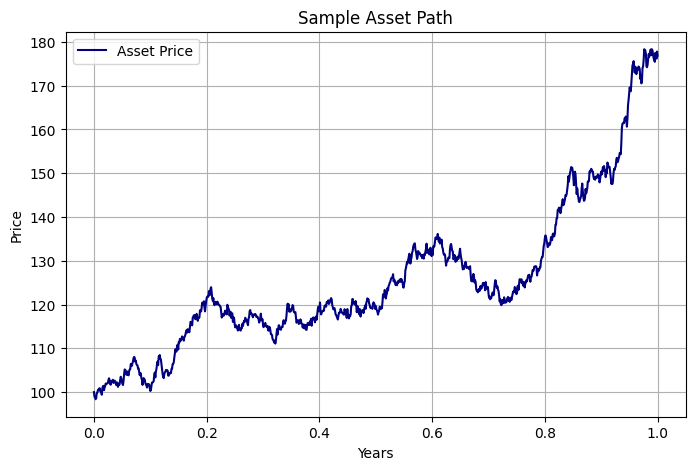

In [9]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.underlying[path_index], color='navy', label=f"Asset Price")

plt.title("Sample Asset Path")
plt.xlabel("Years")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/asset_path.png')

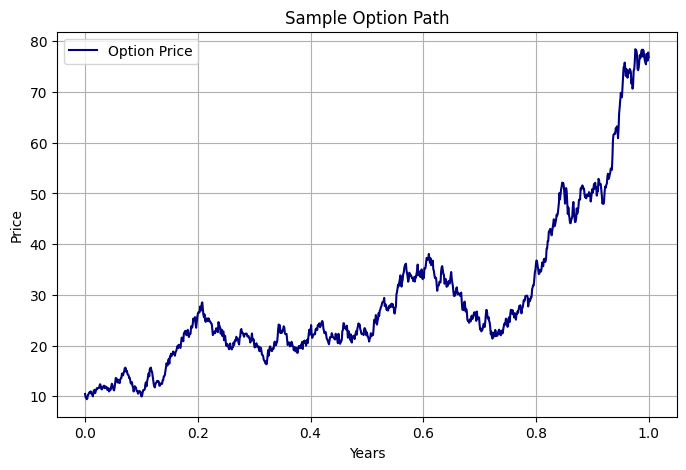

In [10]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.option[path_index], color='navy', label=f"Option Price")

plt.title("Sample Option Path")
plt.xlabel("Years")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/option_path.png')

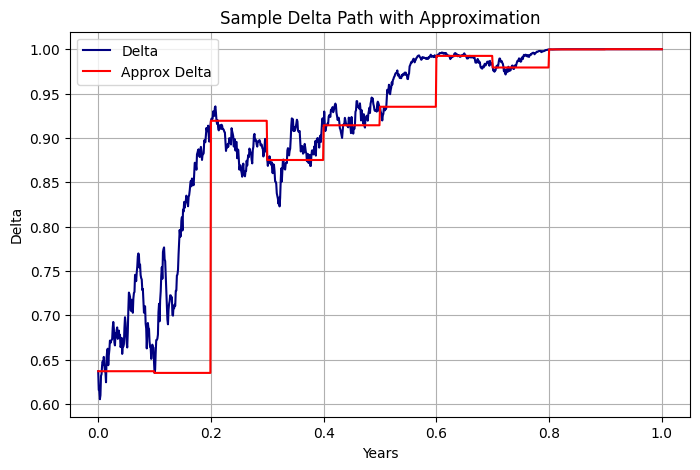

In [11]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.true_delta[path_index], color='navy', label=f"Delta")
plt.plot(hedging_results.time, hedging_results.approx_delta[path_index], color='red', label=f"Approx Delta")

plt.title("Sample Delta Path with Approximation")
plt.xlabel("Years")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/delta_and_approx_paths.png')

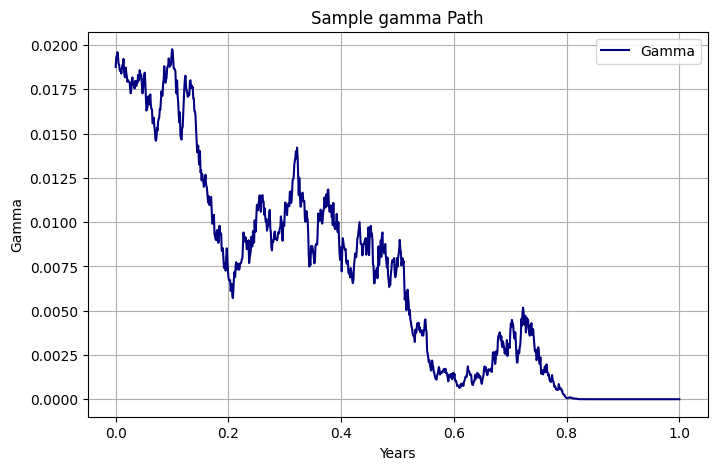

In [12]:
plt.figure(figsize=(8,5))

plt.plot(hedging_results.time, hedging_results.gamma[path_index], color='navy', label=f"Gamma")

# gamma tend to zero at maturity if the option is deep ITM/OTM. gamma blows up at maturity if ATM.
plt.title("Sample gamma Path")
plt.xlabel("Years")
plt.ylabel("Gamma")
plt.legend()
plt.grid(True)
if save_figures:
    plt.savefig('../figures/gamma_path.png')

### Portfolio Profit & Loss

Control group (no hedging):

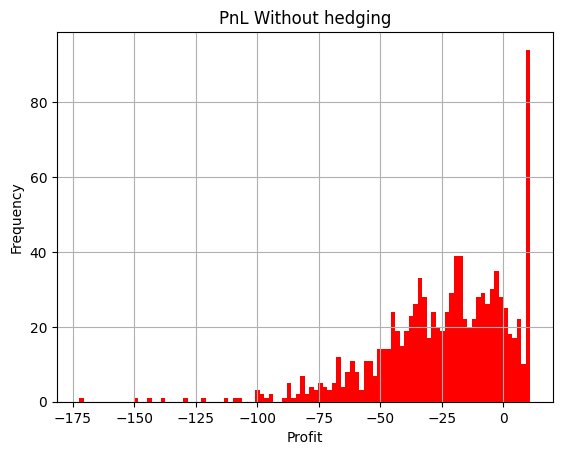

In [13]:
current_asset_price = np.zeros(runs)
current_asset_price[:] = asset.simulate(maturity, runs, mesh)[:,0]
final_asset_price = np.zeros(runs)
final_asset_price[:] = asset.simulate(maturity, runs, mesh)[:,-1]
no_hedge_pnl = option.price(current_asset_price, 0, rate, sigma)*np.exp(rate*maturity) - option.payoff(final_asset_price)

plt.hist(no_hedge_pnl, bins=100, density=False, color='red')

plt.title("PnL Without hedging")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.grid(True)
if save_figures:
    plt.savefig('../figures/PnL_without_hedge.png')

Delta hedged portfolio:

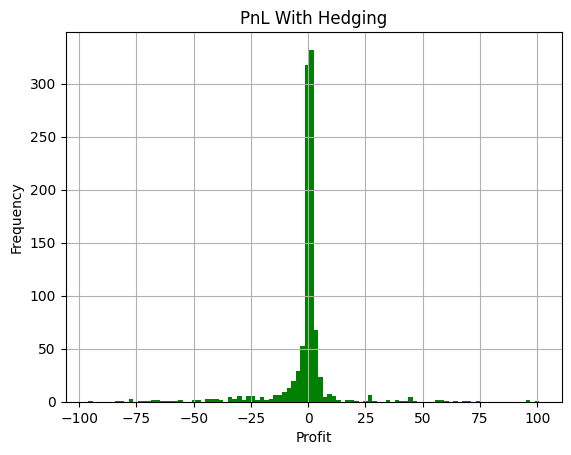

In [14]:
plt.hist(hedging_results.pnl, bins=100, density=False, color='green')

plt.title("PnL With Hedging")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.grid(True)
if save_figures:
    plt.savefig('../figures/PnL_with_hedge.png')

Summary statistics:

In [15]:
print(f'No hedging: Mean PnL= {np.mean(no_hedge_pnl):.2f}, Stddev PnL= {np.std(no_hedge_pnl):.6f}')
print(f'Hedging: Mean PnL= {np.mean(hedging_results.pnl):.2f}, Stddev PnL= {np.std(hedging_results.pnl):.6f}')

No hedging: Mean PnL= -24.03, Stddev PnL= 26.361916
Hedging: Mean PnL= -1.21, Stddev PnL= 15.728070


### Independence of Drift

### Convergence Test

In [16]:
dt_values = 1 / (2 ** np.arange(10))
pnl_var = []

for dt in dt_values:
    hedging_results = DeltaHedgingEngine(option, asset).run(rate, sigma, runs, dt, random_seed=1973)
    v = np.var(hedging_results.pnl)
    pnl_var.append(v)

pnl_var = [float(_) for _ in pnl_var]

Estimated convergence rate: 0.565


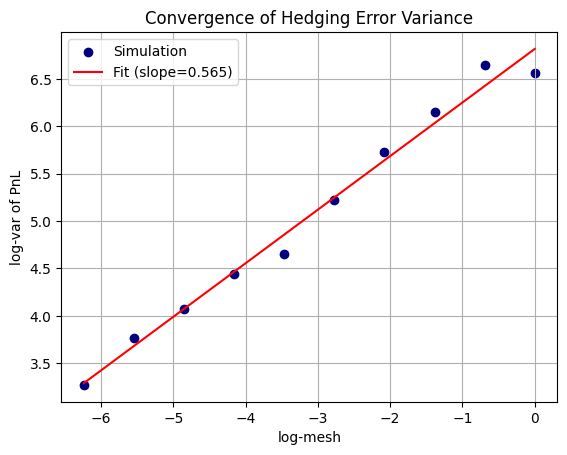

In [17]:
log_dt = np.log(np.array(dt_values))
log_var = np.log(np.array(pnl_var))

slope, intercept = np.polyfit(log_dt, log_var, 1)

print(f"Estimated convergence rate: {slope:.3f}")

plt.scatter(log_dt, log_var, color='navy', label="Simulation")
plt.plot(log_dt, slope*log_dt + intercept, color='red', label=f"Fit (slope={slope:.3f})")

plt.xlabel("log-mesh")
plt.ylabel("log-var of PnL")
plt.legend()
plt.title("Convergence of Hedging Error Variance")
plt.grid(True)
if save_figures:
    plt.savefig('../figures/loglog_plot_of_error_vs_dt.png')